In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [54]:
train_df = pd.read_csv("dataset/fraudTrain.csv")
test_df = pd.read_csv("dataset/fraudTest.csv")

In [55]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [56]:
train_df.shape

(1296675, 23)

In [57]:
test_df.shape

(555719, 23)

In [58]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [59]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [60]:
train_df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [61]:
train_df.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [62]:
train_df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [63]:
train_df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

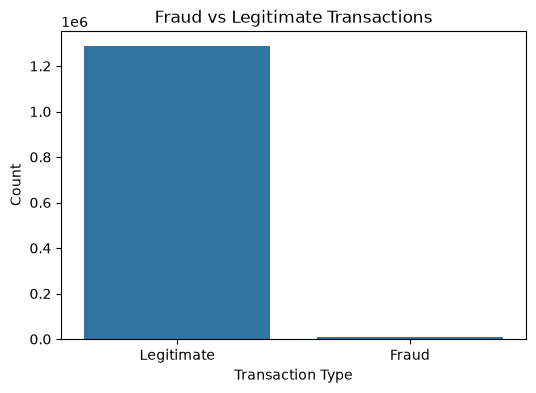

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=train_df)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

In [ ]:
features = [
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "unix_time"
]

X_train = train_df[features]
y_train = train_df["is_fraud"]

X_test = test_df[features]
y_test = test_df["is_fraud"]

In [100]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Data:")
print(y_train.value_counts())

print("\nAfter Applying SMOTE:")
print(y_train_smote.value_counts())

Original Training Data:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

After Applying SMOTE:
is_fraud
0    1289169
1    1289169
Name: count, dtype: int64


In [66]:
print(X_train.shape)
print(X_test.shape)

(1296675, 7)
(555719, 7)


In [67]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [68]:
log_pred = log_model.predict(X_test)

In [69]:
accuracy = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {accuracy*100:.2f}%")

Logistic Regression Accuracy: 99.61%


In [70]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



c:\Users\VAHINI\Documents\CodSoft_Machine_Learning_Internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VAHINI\Documents\CodSoft_Machine_Learning_Internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\VAHINI\Documents\CodSoft_Machine_Learning_Internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

In [101]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [72]:
rf_pred = rf_model.predict(X_test)

In [73]:
accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {accuracy*100:.2f}%")

Random Forest Accuracy: 99.60%


In [74]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.02      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.51      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



In [75]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [76]:
dt_pred = dt_model.predict(X_test)

In [77]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy*100:.2f}%")

Decision Tree Accuracy: 98.80%


In [78]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.09      0.23      0.13      2145

    accuracy                           0.99    555719
   macro avg       0.54      0.61      0.56    555719
weighted avg       0.99      0.99      0.99    555719



In [79]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.996140
1,Decision Tree,0.987998
2,Random Forest,0.996047


In [80]:
best_model = results.loc[results["Accuracy"].idxmax()]

print(best_model)

Model       Logistic Regression
Accuracy                0.99614
Name: 0, dtype: object


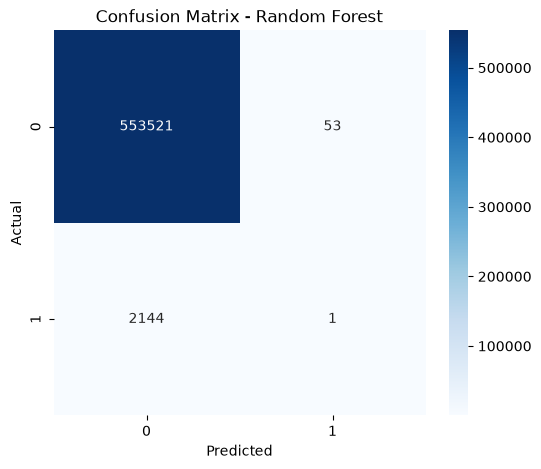

In [81]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Conclusion

Three machine learning algorithms were implemented for credit card fraud detection:

- Logistic Regression
- Decision Tree
- Random Forest

The models achieved high overall accuracy on the dataset. The models achieved high overall accuracy on the dataset. Logistic Regression achieved the highest accuracy of 99.61%, followed closely by Random Forest with 99.60%, while Decision Tree achieved 98.80%. This project demonstrates how machine learning algorithms can be used to classify credit card transactions as legitimate or fraudulent. Since the dataset is highly imbalanced, overall accuracy alone is not sufficient to evaluate fraud detection performance, but all three models successfully demonstrate the application of machine learning techniques for transaction classification.

In [84]:
import pandas as pd

In [86]:
import pandas as pd

fraudTest = pd.read_csv("dataset/fraudTest.csv")

In [87]:
import os

print(os.getcwd())

c:\Users\VAHINI\Documents\CodSoft_Machine_Learning_Internship\Task_2_Credit_Card_Fraud_Detection


In [88]:
import os

print(os.listdir())

['.venv', 'credit_card_fraud_detection.ipynb', 'dataset', 'README.md']


In [89]:
import os

print(os.listdir("dataset"))

['fraudTest.csv', 'fraudTrain.csv']


In [90]:
fraudTest = pd.read_csv(r"dataset\fraudTest.csv")

In [91]:
fraudTest = pd.read_csv("dataset/fraudTest.csv")

In [92]:
fraudTest[fraudTest["is_fraud"] == 1][
    [
        "amt",
        "city_pop",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "unix_time"
    ]
].head(5)

,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
1685,24.84,23,31.8599,-102.7413,32.575873,-102.604290,1371852399
1767,780.52,1306,42.5545,-90.3508,42.461127,-91.147148,1371853942
1781,620.33,1306,42.5545,-90.3508,42.771834,-90.158365,1371854247
1784,1077.69,71335,30.4590,-90.9027,31.204974,-90.261595,1371854335
1857,842.65,23,31.8599,-102.7413,31.315782,-102.736390,1371855736


In [93]:
fraudTest[fraudTest["is_fraud"] == 0][
    [
        "amt",
        "city_pop",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "unix_time"
    ]
].head(5)

,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
0,2.86,333497,33.9659,-80.9355,33.986391,-81.200714,1371816865
1,29.84,302,40.3207,-110.4360,39.450498,-109.960431,1371816873
2,41.28,34496,40.6729,-73.5365,40.495810,-74.196111,1371816893
3,60.05,54767,28.5697,-80.8191,28.812398,-80.883061,1371816915
4,3.19,1126,44.2529,-85.0170,44.959148,-85.884734,1371816917


In [95]:
print(train_df["is_fraud"].value_counts())

print()

print(train_df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [96]:
from sklearn.metrics import confusion_matrix

rf_pred = rf_model.predict(X_test)

print(confusion_matrix(y_test, rf_pred))

[[553521     53]
 [  2144      1]]


In [97]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Data:")
print(y_train.value_counts())

print("\nAfter Applying SMOTE:")
print(y_train_smote.value_counts())

Original Training Data:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

After Applying SMOTE:
is_fraud
0    1289169
1    1289169
Name: count, dtype: int64


In [99]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9960465631011356

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.02      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.51      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719


Confusion Matrix:

[[553521     53]
 [  2144      1]]


In [102]:
rf_pred = rf_model.predict(X_test)

In [103]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print()
print(classification_report(y_test, rf_pred))

[[551892   1682]
 [  2003    142]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.08      0.07      0.07      2145

    accuracy                           0.99    555719
   macro avg       0.54      0.53      0.53    555719
weighted avg       0.99      0.99      0.99    555719



In [104]:
fraudTest[fraudTest["is_fraud"] == 1][
    ["amt","city_pop","lat","long","merch_lat","merch_long","unix_time"]
].head(1)

,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
1685,24.84,23,31.8599,-102.7413,32.575873,-102.60429,1371852399


In [105]:
fraudTest[fraudTest["is_fraud"] == 0][
    ["amt","city_pop","lat","long","merch_lat","merch_long","unix_time"]
].head(1)

,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
0,2.86,333497,33.9659,-80.9355,33.986391,-81.200714,1371816865


In [107]:
import ipywidgets as widgets
from IPython.display import display, HTML

# -------------------------
# Input Fields
# -------------------------

amt = widgets.Text(
    value="",
    placeholder="Enter Transaction Amount",
    description="Amount:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

city_pop = widgets.Text(
    value="",
    placeholder="Enter City Population",
    description="City Pop:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

lat = widgets.Text(
    value="",
    placeholder="Enter Customer Latitude",
    description="Customer Latitude:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

long = widgets.Text(
    value="",
    placeholder="Enter Customer Longitude",
    description="Customer Longitude:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

merch_lat = widgets.Text(
    value="",
    placeholder="Enter Merchant Latitude",
    description="Merchant Lat:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

merch_long = widgets.Text(
    value="",
    placeholder="Enter Merchant Longitude",
    description="Merchant Long:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

unix_time = widgets.Text(
    value="",
    placeholder="Enter Unix Time",
    description="Unix Time:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

# -------------------------
# Predict Button
# -------------------------

button = widgets.Button(
    description="Predict",
    button_style="primary",
    icon="check",
    layout=widgets.Layout(width="180px", height="45px")
)

output = widgets.Output()

display(HTML("<h2>💳 Credit Card Fraud Detection</h2>"))

display(
    amt,
    city_pop,
    lat,
    long,
    merch_lat,
    merch_long,
    unix_time,
    button,
    output
)

# -------------------------
# Prediction Function
# -------------------------

def predict_transaction(b):

    output.clear_output()

    # Check for empty fields
    fields = {
        "Transaction Amount": amt.value,
        "City Population": city_pop.value,
        "Customer Latitude": lat.value,
        "Customer Longitude": long.value,
        "Merchant Latitude": merch_lat.value,
        "Merchant Longitude": merch_long.value,
        "Unix Time": unix_time.value
    }

    for name, value in fields.items():
        if value.strip() == "":
            with output:
                display(HTML(
                    f"<h3 style='color:red;'>❌ Please enter {name}.</h3>"
                ))
            return

    # Check numeric values
    try:

        sample = [[
            float(amt.value),
            float(city_pop.value),
            float(lat.value),
            float(long.value),
            float(merch_lat.value),
            float(merch_long.value),
            float(unix_time.value)
        ]]

    except ValueError:

        with output:
            display(HTML(
                "<h3 style='color:red;'>❌ Please enter valid numeric values only.</h3>"
            ))
        return

    # Prediction
    prediction = rf_model.predict(sample)

    with output:

        if prediction[0] == 1:
            display(HTML(
                """
                <h1 style='color:red;
                           font-size:38px;
                           font-weight:bold;'>
                🚨 Fraudulent Transaction
                </h1>
                """
            ))

        else:
            display(HTML(
                """
                <h1 style='color:green;
                           font-size:38px;
                           font-weight:bold;'>
                ✅ Legitimate Transaction
                </h1>
                """
            ))

button.on_click(predict_transaction)

Text(value='', description='Amount:', layout=Layout(width='450px'), placeholder='Enter Transaction Amount', st…

Text(value='', description='City Pop:', layout=Layout(width='450px'), placeholder='Enter City Population', sty…

Text(value='', description='Customer Latitude:', layout=Layout(width='450px'), placeholder='Enter Customer Lat…

Text(value='', description='Customer Longitude:', layout=Layout(width='450px'), placeholder='Enter Customer Lo…

Text(value='', description='Merchant Lat:', layout=Layout(width='450px'), placeholder='Enter Merchant Latitude…

Text(value='', description='Merchant Long:', layout=Layout(width='450px'), placeholder='Enter Merchant Longitu…

Text(value='', description='Unix Time:', layout=Layout(width='450px'), placeholder='Enter Unix Time', style=Te…

Button(button_style='primary', description='Predict', icon='check', layout=Layout(height='45px', width='180px'…

Output()